In [1]:
import numpy as np
import pandas as pd
from scipy.cluster import hierarchy as sch

from matplotlib import pyplot as plt

import scanpy as sc
import squidpy as sq

import matplotlib as mpl
import matplotlib.pyplot as plt

import os

mpl.rcParams['pdf.fonttype'] = 42      # 关键：使用TrueType字体
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['font.sans-serif'] = 'Arial'

folder = '/Users/zyr/Documents/projects/Breast-mouse/'
os.chdir(folder)

/opt/anaconda3/envs/xenium-env/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/anaconda3/envs/xenium-env/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [ ]:
def calculate_celltype_proportions(adata, group_by='group', celltype_col='cell_type'):

    counts_df = adata.obs.groupby([group_by, celltype_col]).size().unstack(fill_value=0)
    
   
    proportions_df = counts_df.div(counts_df.sum(axis=1), axis=0)
    
    return proportions_df, counts_df

def plot_stacked_bar(proportions_df, title='Cell Type Proportions by Group', 
                     figsize=(8, 6), palette='Set2', colors = None, save_path=None):

    fig, ax = plt.subplots(figsize=figsize)
    
    # mapping color
    if colors:
        colors = colors
    else:
        colors = sns.color_palette(palette, n_colors=len(proportions_df.columns))
    
    # barplot
    proportions_df.plot(kind='bar', stacked=True, ax=ax, color=colors, 
                       #edgecolor='white', 
                       # linewidth=0.5
                       )

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)
    ax.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    

    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


def plot_boxplot(plot_data, xlab, ylab, compare_pairs):
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.boxplot(data=plot_data, x=xlab, y=ylab,width=0.6,fliersize=0.3)
    pairs = compare_pairs
    annotator = Annotator(ax, pairs, data=plot_data, x=xlab, y=ylab)
    annotator.configure(test='t-test_welch', text_format='star', loc='inside')
    annotator.apply_and_annotate()
    legend = ax.legend()
    legend.remove()

In [3]:
data = sc.read_h5ad('./data/scRNA/Seno_full_scvi_meta.h5ad')

In [4]:
data

AnnData object with n_obs × n_vars = 47701 × 19890
    obs: 'Barcode', 'Lane_ID', 'Sample', 'Mouse_ID', 'Batch', 'Dataset', 'Age', 'Genotype', 'Treatment', 'Doublet_score', 'Doublet_type', 'Doublet_threshold', 'n_genes', 'n_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'Parity', 'Condition', 'subsets_Mito_percent', 'leiden_0_05', 'leiden_0_1', 'leiden_0_2', 'leiden_0_3', 'leiden_0_4', 'leiden_0_5', 'ct_level1', 'ct_level3', 'pct_mt_final', 'Group', 'Batch_old'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'Symbol'
    uns: 'Batch_colors', 'Doublet_type_colors', 'Mouse_ID_colors', 'Parity_colors', 'ct_level1_colors', 'ct_level3_colors', 'dendrogram_leiden_0_05', 'dendrogram_leiden_0_1', 'dendrogram_leiden_0_2', 'dendrogram_leiden_0_3', 'dendrogram_leiden_0_4', 'dendrogram_leiden_0_5', 'hvg', 'leiden_0_05', 'leiden_0_05_colors', 'leiden_0_1', 'leiden_0_1_colors', 'leiden_0_2', 'leiden_0_2_colors', 'leiden_0_3', 'leiden_0_3_colors', 'leiden_0_4', 

In [23]:
data.obs[['Mouse_ID','Treatment']][data.obs[['Mouse_ID','Treatment']].duplicated() == False]

,Mouse_ID,Treatment
AA21.4f_AAACCCAAGAGGTCGT-1,AA21.4f,Seno_ABT737_control
AA21.4e_AAACCCAAGCGGACAT-1,AA21.4e,Seno_ABT737_control
AA21.4d_AAACCCAAGCATAGGC-1,AA21.4d,Seno_ABT737
AA23.4h_AAACCCAAGACATAGT-1,AA23.4h,Seno_ABT737_control
AA24.4c_AAACCCAAGAACCCGA-1,AA24.4c,Seno_ABT737
AA24.4d_R_AAACCCAAGAGTCACG-1,AA24.4d_R,Seno_ABT737_control


In [25]:
sc.pp.neighbors(data)
sc.tl.umap(data)

/opt/anaconda3/envs/xenium-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
data.uns['ct_level3_colors'] = ['#440154', '#450559', '#460b5e', '#471164', '#481668', '#481b6d',
       '#482071', '#482475', '#482979', '#472e7c', '#46337f', '#453781',
       '#443b84', '#424086', '#414487', '#3f4889', '#3d4d8a', '#3b518b',
       '#3a548c', '#38598c', '#365d8d', '#34608d', '#32648e', '#31688e',
       '#2f6c8e', '#2e6f8e', '#2c728e', '#2a768e', '#29798e', '#287d8e',
       '#26818e', '#25848e', '#24878e', '#228b8d', '#218f8d', '#20928c',
       '#1f958b', '#1f998a', '#1e9c89', '#1fa088', '#20a386', '#22a785',
       '#24aa83', '#27ad81', '#2cb17e', '#2fb47c', '#35b779', '#3bbb75',
       '#42be71', '#48c16e', '#50c46a', '#58c765', '#5ec962', '#67cc5c',
       '#70cf57', '#7ad151', '#81d34d', '#8bd646', '#95d840', '#9dd93b',
       '#a8db34', '#b2dd2d', '#bddf26', '#c5e021', '#d0e11c', '#dae319',
       '#e2e418', '#ece51b', '#f6e620', '#fde725']

data.uns['ct_level3_colors'] = list(mcolors.CSS4_COLORS.values())[0:70]

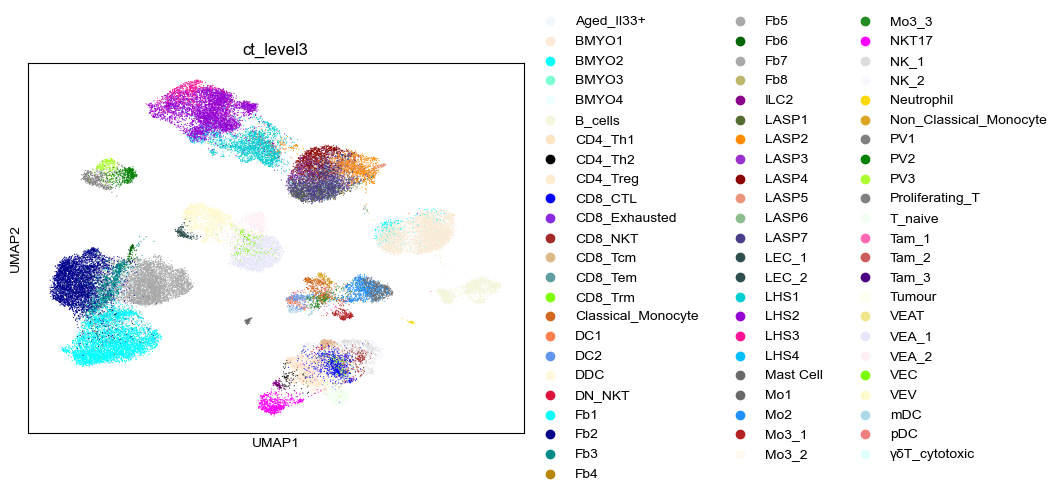

In [52]:
sc.pl.umap(data,color = 'ct_level3')

In [10]:
import matplotlib.colors as mcolors

In [58]:
names

['black',
 'dimgray',
 'dimgrey',
 'gray',
 'grey',
 'darkgray',
 'darkgrey',
 'silver',
 'lightgray',
 'lightgrey',
 'gainsboro',
 'whitesmoke',
 'white',
 'snow',
 'rosybrown',
 'lightcoral',
 'indianred',
 'brown',
 'firebrick',
 'maroon',
 'darkred',
 'red',
 'mistyrose',
 'salmon',
 'tomato',
 'darksalmon',
 'coral',
 'orangered',
 'lightsalmon',
 'sienna',
 'seashell',
 'chocolate',
 'saddlebrown',
 'sandybrown',
 'peachpuff',
 'peru',
 'linen',
 'bisque',
 'darkorange',
 'burlywood',
 'antiquewhite',
 'tan',
 'navajowhite',
 'blanchedalmond',
 'papayawhip',
 'moccasin',
 'orange',
 'wheat',
 'oldlace',
 'floralwhite',
 'darkgoldenrod',
 'goldenrod',
 'cornsilk',
 'gold',
 'lemonchiffon',
 'khaki',
 'palegoldenrod',
 'darkkhaki',
 'ivory',
 'beige',
 'lightyellow',
 'lightgoldenrodyellow',
 'olive',
 'yellow',
 'olivedrab',
 'yellowgreen',
 'darkolivegreen',
 'greenyellow',
 'chartreuse',
 'lawngreen',
 'honeydew',
 'darkseagreen',
 'palegreen',
 'lightgreen',
 'forestgreen',
 'l

In [ ]:
xx = [colors[x] for x in names]
xx

In [64]:
data.uns['ct_level3_colors'] = xx[15:85]

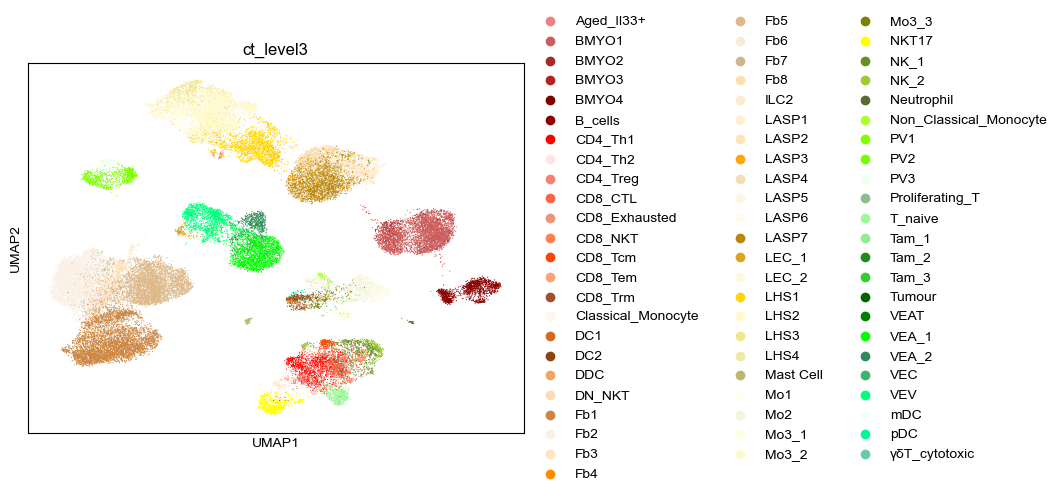

In [66]:
sc.pl.umap(data,color = 'ct_level3')

In [ ]:
from distinctipy import distinctipy

colors = distinctipy.get_colors(70)


/opt/anaconda3/envs/xenium-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1154: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)


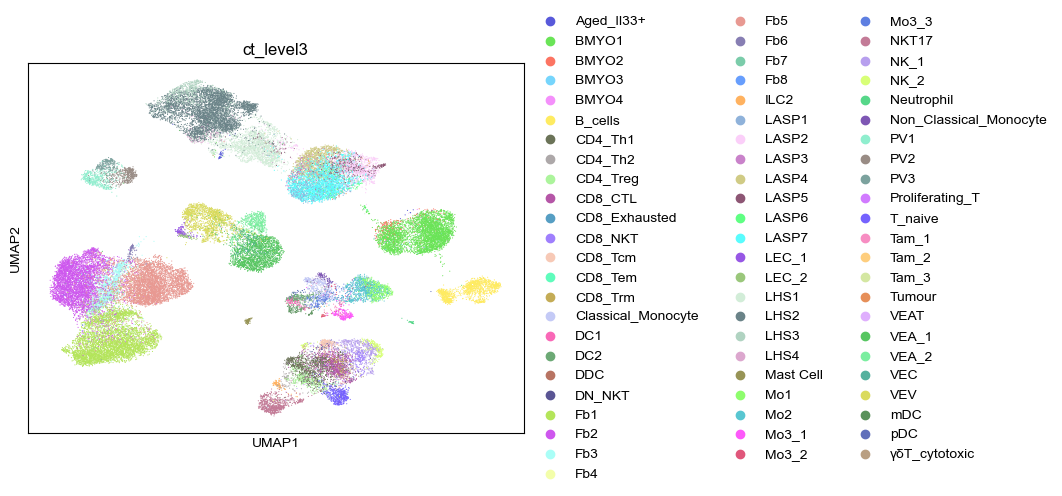

In [ ]:
colors = distinctipy.get_colors(
    70,
    pastel_factor=0.5  
)

data.uns['ct_level3_colors'] = colors
sc.pl.umap(data,color = 'ct_level3')

/opt/anaconda3/envs/xenium-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1154: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)


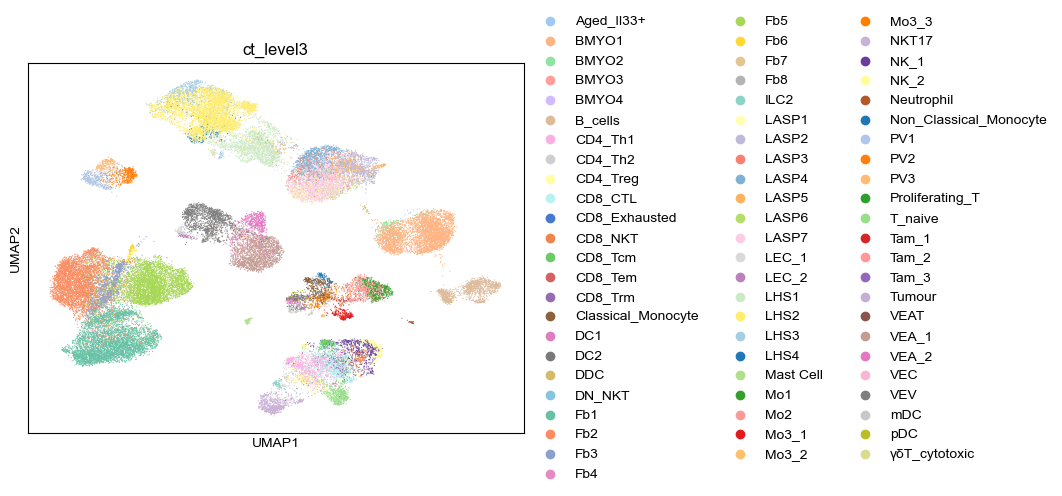

In [15]:
import seaborn as sns
palettes = [
    sns.color_palette("pastel", 10),
    sns.color_palette("muted", 10),
    sns.color_palette("Set2", 8),
    sns.color_palette("Set3", 12),
    sns.color_palette("Paired", 12),
    sns.color_palette("tab20", 20),
]

colors = []
for p in palettes:
    colors.extend(p)

colors = colors[:70]

data.uns['ct_level3_colors'] = colors
sc.pl.umap(data,color = 'ct_level3')

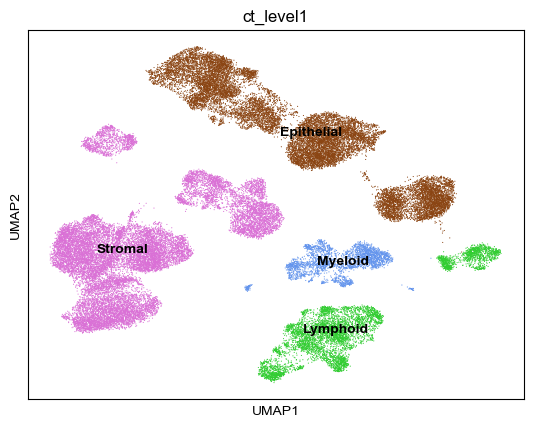

In [122]:
colors = mcolors.CSS4_COLORS

data.uns['ct_level1_colors'] = [colors['saddlebrown'],colors['limegreen'],colors['cornflowerblue'],colors['orchid']]
sc.pl.umap(data,color = 'ct_level1',legend_loc='on data',save='_senolytic_annotation_level1.pdf')

In [ ]:
sc.pl.umap(data,color = 'ct_level1',legend_loc='on data')

/opt/anaconda3/envs/xenium-env/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1154: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)


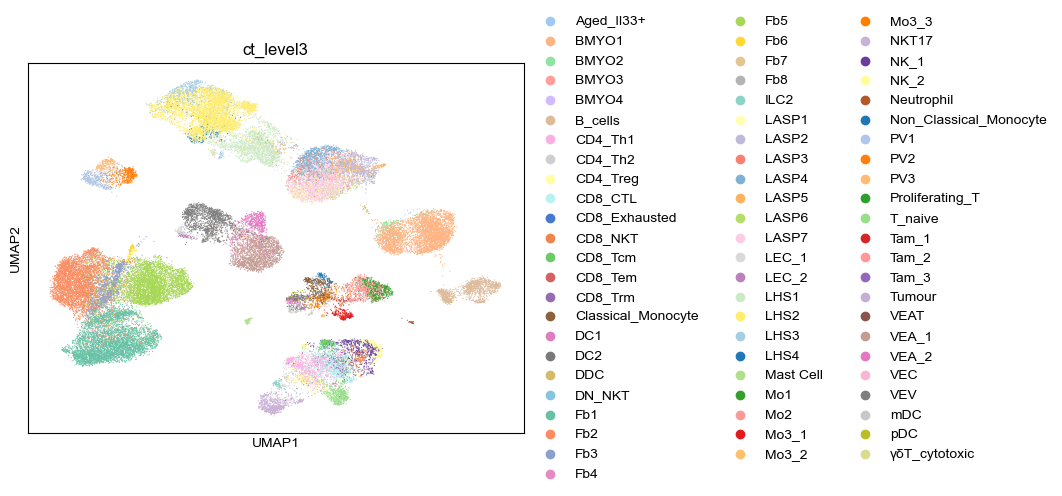

In [94]:
sc.settings.figdir = '/Users/zyr/Documents/projects/Breast-mouse/figures/scRNA/'
sc.pl.umap(data,color = 'ct_level3',save='senolytic_annotation.pdf')

In [23]:
prop_df, count_df = calculate_celltype_proportions(data, 
                                                   group_by='Treatment',celltype_col='ct_level3')
prop_df = prop_df.iloc[[1,0],:]
prop_df.index = ['Vehicle','ABT737']
prop_df

/var/folders/mk/00h7rt8s3dx5fg_kl3xx4nqw0000gn/T/ipykernel_42976/1202275131.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_df = adata.obs.groupby([group_by, celltype_col]).size().unstack(fill_value=0)


ct_level3,Aged_Il33+,BMYO1,BMYO2,BMYO3,BMYO4,B_cells,CD4_Th1,CD4_Th2,CD4_Treg,CD8_CTL,...,Tam_3,Tumour,VEAT,VEA_1,VEA_2,VEC,VEV,mDC,pDC,γδT_cytotoxic
Vehicle,0.000449,0.090527,0.003527,0.001026,0.000032,0.042554,0.015393,0.002213,0.009620,0.016002,...,0.000064,0.000257,0.000385,0.049737,0.010679,0.003111,0.024179,0.001764,0.000705,0.000962
ABT737,0.001574,0.072229,0.005873,0.001332,0.000969,0.002664,0.025731,0.002361,0.003996,0.017134,...,0.000061,0.000061,0.000000,0.029485,0.013380,0.003330,0.041836,0.001877,0.001029,0.000303


/var/folders/mk/00h7rt8s3dx5fg_kl3xx4nqw0000gn/T/ipykernel_42976/1202275131.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


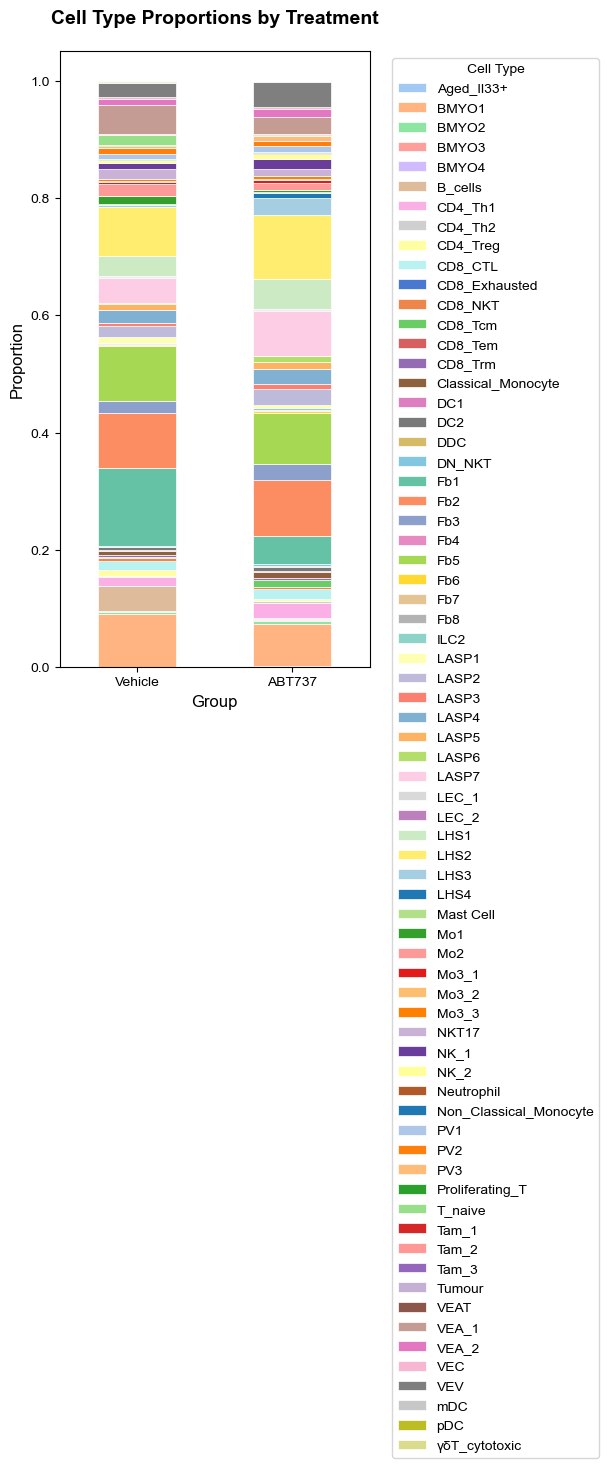

In [25]:
plot_stacked_bar(prop_df, title='Cell Type Proportions by Treatment',colors = data.uns['ct_level3_colors'],figsize=(4,8),
                save_path = '/Users/zyr/Documents/projects/Breast-mouse/figures/scRNA/barplot_senolytic_cellProportion_subsets.pdf')

/var/folders/mk/00h7rt8s3dx5fg_kl3xx4nqw0000gn/T/ipykernel_2839/1202275131.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_df = adata.obs.groupby([group_by, celltype_col]).size().unstack(fill_value=0)


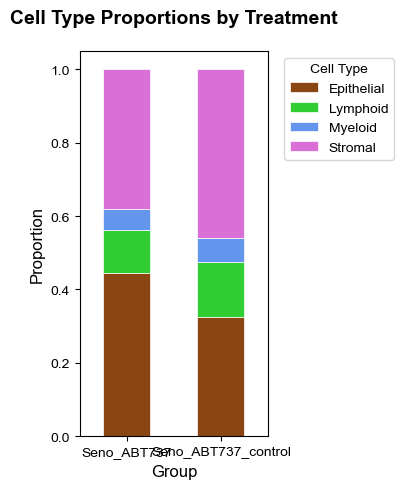

In [126]:
prop_df, count_df = calculate_celltype_proportions(data, 
                                                   group_by='Treatment',celltype_col='ct_level1')
plot_stacked_bar(prop_df, title='Cell Type Proportions by Treatment',colors = data.uns['ct_level1_colors'],figsize=(4,5),
                save_path = '/Users/zyr/Documents/projects/Breast-mouse/figures/scRNA/barplot_senolytic_cellProportion_level1.pdf')

In [57]:
data.uns['Treatment_colors'] = ['#CD5C5C','#1E90FF']

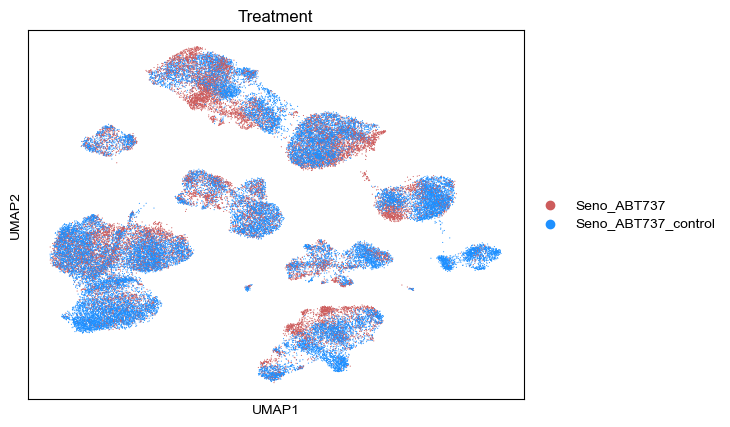

In [61]:
sc.settings.figdir = '/Users/zyr/Documents/projects/Breast-mouse/figures/scRNA/'
sc.pl.umap(data,color = 'Treatment',save='_senolytic_treatment.pdf')

In [79]:
adata_anno_map={
    'LASP1': 'LASP',
    'LASP2': 'LASP',
    'LASP3': 'LASP',
    'LASP4': 'LASP',
    'LASP5': 'LASP',
    'LASP6': 'LASP',
    'LASP7': 'LASP',
    'LHS1': 'LHS',
    'LHS2': 'LHS',
    'LHS3': 'LHS',
    'LHS4': 'LHS',
    'Fb1': 'Fibroblast',
    'Fb2': 'Fibroblast',
    'Fb3': 'Fibroblast',
    'Fb4': 'Fibroblast',
    'Fb5': 'Fibroblast',
    'Fb6': 'Fibroblast',
    'Fb7': 'Fibroblast',
    'Fb8': 'Fibroblast',
    'B_cells': 'B_cell',
    'BMYO1': 'BMYO',
    'BMYO2': 'BMYO',
    'BMYO3': 'BMYO',
    'BMYO4': 'BMYO',
    'CD8_Trm': 'T_cells',
    'CD8_CTL': 'T_cells',
    'CD8_Tcm': 'T_cells',
    'CD8_Tem': 'T_cells',
    'CD8_Exhausted': 'T_cells',
    'CD8_NKT': 'T_cells',
    'CD4_Th1': 'T_cells',
    'CD4_Th2': 'T_cells',
    'CD4_Treg': 'T_cells',
    'NKT17': 'T_cells',
    'NK_1': 'T_cells',
    'NK_2': 'T_cells',
    'γδT_cytotoxic': 'T_cells',
    'Proliferating_T': 'T_cells',
    'Aged_Il33+': 'Aged Il33+',
    'DN_NKT': 'T_cells',
    'DDC':'DDC',
    'Tam_1': 'Tam',
    'Tam_2': 'Tam',
    'Tam_3': 'Tam',
    'Mo2': 'Mac/Mono',
    'Mo1': 'Mac/Mono',
    'Mo3_1': 'Mac/Mono',
    'Mo3_2': 'Mac/Mono',
    'Mo3_3': 'Mac/Mono',
    'pDC': 'DC',
    'mDC': 'DC',
    'DC1': 'DC',
    'DC2': 'DC',
    'Non_Classical_Monocyte': 'Mac/Mono',
    'Classical_Monocyte': 'Mac/Mono',
    'Mast Cell': 'Mast_cells',
    'ILC2': 'ILC2',
    'Tumour': 'Tumour-like',
    'Neutrophil': 'Neutrophil',
    'T_naive': 'T_cells',
    'VEA_1': 'Vascular endothelium',
    'LEC_1': 'Vascular endothelium',
    'VEV': 'Vascular endothelium',
    'LEC_2': 'Vascular endothelium',
    'PV1': 'Perivascular',
    'PV3': 'Perivascular',
    'PV2': 'Perivascular',
    'VEA_2': 'Vascular endothelium',
    'VEC': 'Vascular endothelium',
    'VEAT': 'Vascular endothelium',}

In [83]:
data.obs['ct_level2'] = data.obs['ct_level3'].map(adata_anno_map)
list(data.obs['ct_level2'].sort_values().unique())

['Aged Il33+',
 'BMYO',
 'B_cell',
 'DC',
 'DDC',
 'Fibroblast',
 'ILC2',
 'LASP',
 'LHS',
 'Mac/Mono',
 'Mast_cells',
 'Neutrophil',
 'Perivascular',
 'T_cells',
 'Tam',
 'Tumour-like',
 'Vascular endothelium']

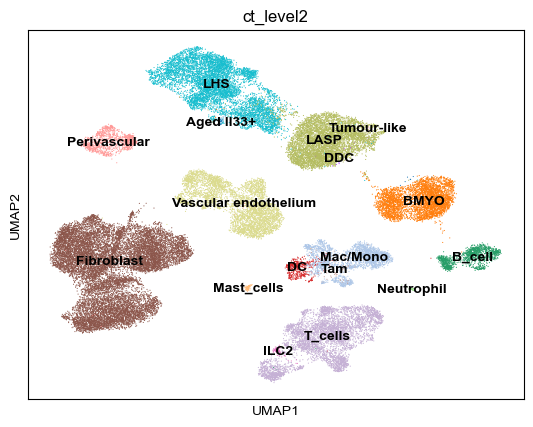

In [85]:
sc.pl.umap(data,color = 'ct_level2',legend_loc='on data')

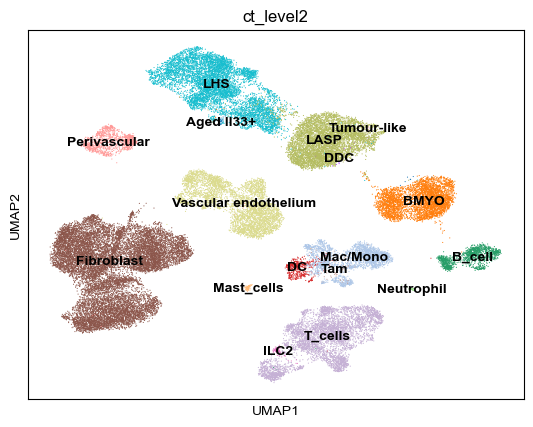

In [87]:
sc.pl.umap(data,color = 'ct_level2',legend_loc='on data',save='_senolytic_annotation_majorSubs_parivascular.pdf')

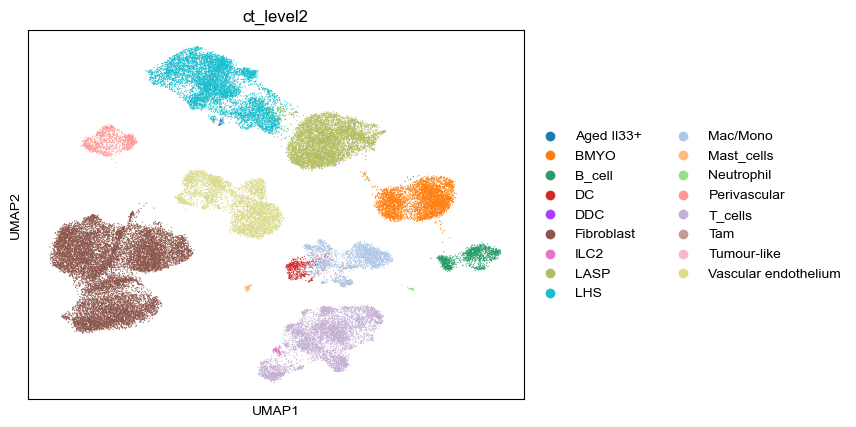

In [89]:
sc.pl.umap(data,color = 'ct_level2',save='_senolytic_annotation_majorSubs_parivascular_legend.pdf')

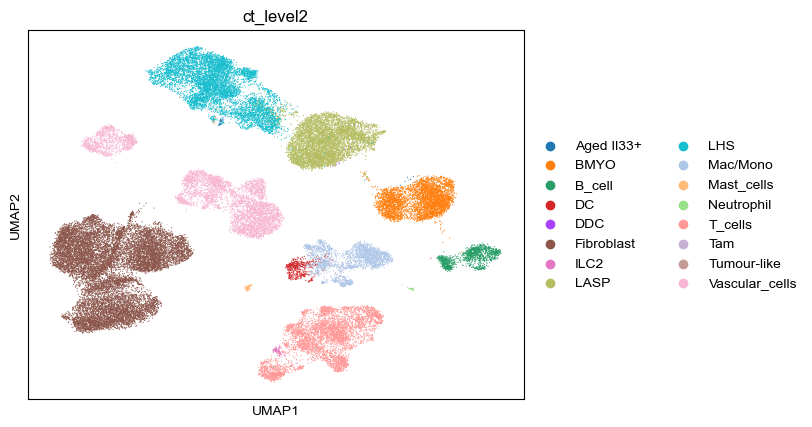

In [69]:
import seaborn as sns
palettes = [
    sns.color_palette("pastel", 10),
    sns.color_palette("muted", 10),
    sns.color_palette("Set2", 8),
    sns.color_palette("Set3", 12),
    sns.color_palette("Paired", 12),
    sns.color_palette("tab20", 20),
]

colors = []
for p in palettes:
    colors.extend(p)

colors = colors[9:25]

sc.settings.figdir = '/Users/zyr/Documents/projects/Breast-mouse/figures/scRNA/'

data.uns['ct_level2_colors'] = []
sc.pl.umap(data,color = 'ct_level2',color_map='tab20',save='_senolytic_annotation_majorSubs.pdf')

/var/folders/mk/00h7rt8s3dx5fg_kl3xx4nqw0000gn/T/ipykernel_6627/1202275131.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_df = adata.obs.groupby([group_by, celltype_col]).size().unstack(fill_value=0)


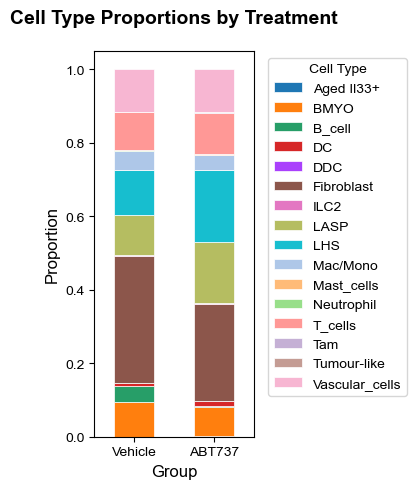

In [73]:
prop_df, count_df = calculate_celltype_proportions(data, 
                                                   group_by='Treatment',celltype_col='ct_level2')
prop_df = prop_df.iloc[[1,0],:]
prop_df.index = ['Vehicle','ABT737']
plot_stacked_bar(prop_df, title='Cell Type Proportions by Treatment',colors = data.uns['ct_level2_colors'],figsize=(4,5),
                save_path = '/Users/zyr/Documents/projects/Breast-mouse/figures/scRNA/barplot_senolytic_cellProportion_majorSubs.pdf')

/var/folders/mk/00h7rt8s3dx5fg_kl3xx4nqw0000gn/T/ipykernel_6627/2108304299.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_df = adata.obs.groupby([group_by, celltype_col]).size().unstack(fill_value=0)


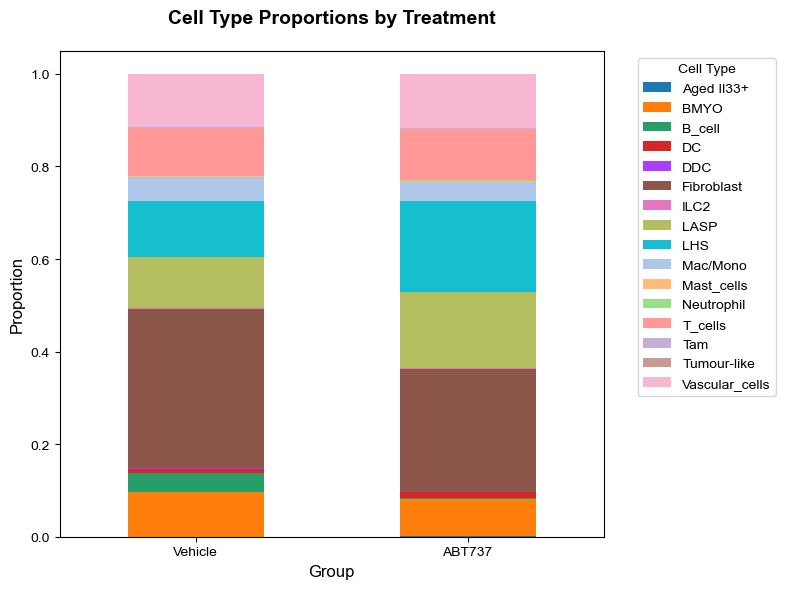

In [77]:
prop_df, count_df = calculate_celltype_proportions(data, 
                                                   group_by='Treatment',celltype_col='ct_level2')
prop_df = prop_df.iloc[[1,0],:]
prop_df.index = ['Vehicle','ABT737']
plot_stacked_bar(prop_df, title='Cell Type Proportions by Treatment',colors = data.uns['ct_level2_colors'])

/var/folders/mk/00h7rt8s3dx5fg_kl3xx4nqw0000gn/T/ipykernel_6627/2108304299.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_df = adata.obs.groupby([group_by, celltype_col]).size().unstack(fill_value=0)


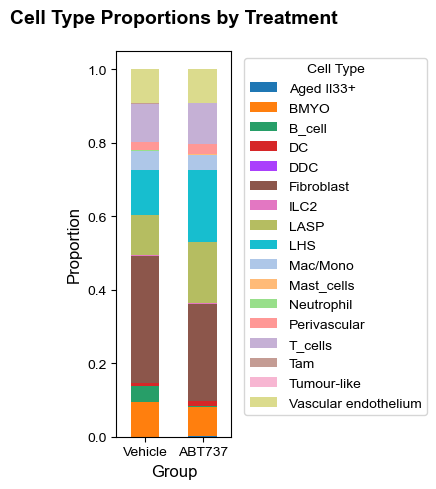

In [91]:
prop_df, count_df = calculate_celltype_proportions(data, 
                                                   group_by='Treatment',celltype_col='ct_level2')
prop_df = prop_df.iloc[[1,0],:]
prop_df.index = ['Vehicle','ABT737']
plot_stacked_bar(prop_df, title='Cell Type Proportions by Treatment',colors = data.uns['ct_level2_colors'],figsize=(4,5),
                save_path = '/Users/zyr/Documents/projects/Breast-mouse/figures/scRNA/barplot_senolytic_cellProportion_majorSubs_parivascular.pdf')